# Music4All EDA for Recommendation and Generation

This notebook is a cleaned, analysis-oriented EDA over the local `music4all` dataset.

It has two goals:
1. **Data readiness check**: confirm the catalog and key tables are usable.
2. **Pipeline-facing analysis**: summarize user/song behavior patterns that matter for recommendation and downstream song generation.

To keep the story clear, the main results are concentrated in the focused EDA section, and repeated exploratory snippets are marked as legacy reference.

## 1. Data Readiness Check Snapshot

In [1]:
from pathlib import Path
import os
import pandas as pd

DATA_PATH = Path('../music4all')

symlink_target = None
symlink_error = None
if DATA_PATH.is_symlink():
    try:
        symlink_target = os.readlink(DATA_PATH)
    except OSError as e:
        symlink_error = str(e)

path_summary = pd.DataFrame([
    {'metric': 'DATA_PATH', 'value': str(DATA_PATH.resolve())},
    {'metric': 'Exists', 'value': bool(DATA_PATH.exists())},
    {'metric': 'Is symlink', 'value': bool(DATA_PATH.is_symlink())},
    {'metric': 'Symlink target', 'value': symlink_target if symlink_target is not None else ''},
    {'metric': 'Symlink read error', 'value': symlink_error if symlink_error is not None else ''},
])

display(path_summary)

,metric,value
0,DATA_PATH,/Users/itsnotjerryh/Desktop/music4all
1,Exists,True
2,Is symlink,True
3,Symlink target,/Users/itsnotjerryh/Desktop/music4all
4,Symlink read error,


In [2]:
from collections import Counter

file_count = 0
dir_count = 0
total_size = 0
ext_counter = Counter()

for root, dirs, files in os.walk(DATA_PATH):
    dir_count += len(dirs)
    for name in files:
        file_count += 1
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            total_size += sz
        except OSError:
            continue
        ext = p.suffix.lower() if p.suffix else '[no_ext]'
        ext_counter[ext] += 1

avg_size = (total_size / file_count) if file_count else 0

inventory_summary = pd.DataFrame([
    {'metric': 'Total files', 'value': int(file_count)},
    {'metric': 'Total dirs', 'value': int(dir_count)},
    {'metric': 'Total size (GB)', 'value': round(float(total_size / (1024**3)), 2)},
    {'metric': 'Average file size (KB)', 'value': round(float(avg_size / 1024), 2)},
])

ext_df = pd.DataFrame(ext_counter.most_common(20), columns=['extension', 'count'])

display(inventory_summary)
display(ext_df)

,metric,value
0,Total files,218546.00
1,Total dirs,2.00
2,Total size (GB),48.85
3,Average file size (KB),234.39


,extension,count
0,.txt,109270
1,.mp3,109269
2,.csv,6
3,[no_ext],1


In [3]:
largest = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        try:
            sz = p.stat().st_size
            largest.append((sz, p))
        except OSError:
            continue

largest.sort(reverse=True, key=lambda x: x[0])
largest_df = pd.DataFrame([
    {'size_mb': round(float(sz / (1024**2)), 2), 'file': str(p.relative_to(DATA_PATH))}
    for sz, p in largest[:20]
])

display(largest_df)

,size_mb,file
0,233.90,listening_history.csv
1,10.13,id_metadata.csv
2,6.68,id_information.csv
3,6.19,id_tags.csv
4,4.02,id_genres.csv
5,2.16,id_lang.csv
6,0.46,audios/fXO7aH7NFHfPHUgo.mp3
7,0.46,audios/UV96BARf3ciHwFi6.mp3
8,0.46,audios/EltvFIDOgIJJPsRi.mp3
9,0.46,audios/pRAt7KPOlZHhsI7g.mp3


In [18]:
from collections import defaultdict

zero_byte = 0
dup_basename = defaultdict(int)
long_paths = 0

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        dup_basename[name] += 1
        if len(str(p)) > 240:
            long_paths += 1
        try:
            if p.stat().st_size == 0:
                zero_byte += 1
        except OSError:
            pass

duplicates = sorted(((k, v) for k, v in dup_basename.items() if v > 1), key=lambda x: x[1], reverse=True)

quality_summary = pd.DataFrame([
    {'metric': 'Zero-byte files', 'value': int(zero_byte)},
    {'metric': 'Paths >240 chars', 'value': int(long_paths)},
    {'metric': 'Duplicate basenames', 'value': int(len(duplicates))},
])

dup_df = pd.DataFrame([
    {
        'basename': name.encode('utf-8', errors='replace').decode('utf-8'),
        'count': int(cnt),
    }
    for name, cnt in duplicates[:20]
])

display(quality_summary)
display(dup_df)

,metric,value
0,Zero-byte files,0
1,Paths >240 chars,0
2,Duplicate basenames,0


""


In [5]:
import random
from datetime import datetime

audio_exts = {'.mp3', '.wav', '.flac', '.m4a', '.aac', '.ogg'}
audio_files = []

for root, _, files in os.walk(DATA_PATH):
    for name in files:
        p = Path(root) / name
        if p.suffix.lower() in audio_exts:
            audio_files.append(p)

sample_n = min(5, len(audio_files))

sample_summary = pd.DataFrame([
    {'metric': 'Found audio files', 'value': int(len(audio_files))},
    {'metric': 'Random sample size', 'value': int(sample_n)},
])

sample_rows = []
for p in random.sample(audio_files, sample_n) if sample_n else []:
    st = p.stat()
    sample_rows.append({
        'file': str(p.relative_to(DATA_PATH)),
        'size_mb': round(float(st.st_size / (1024**2)), 3),
        'modified': datetime.fromtimestamp(st.st_mtime).isoformat(timespec='seconds'),
    })

sample_df = pd.DataFrame(sample_rows)

display(sample_summary)
display(sample_df)

,metric,value
0,Found audio files,109269
1,Random sample size,5


,file,size_mb,modified
0,audios/11GJosg5mxce96dn.mp3,0.458,2019-12-04T19:24:13
1,audios/TBfBUWjNk8hLKArj.mp3,0.459,2019-12-04T19:48:27
2,audios/kwmrxSpfWinq7HmI.mp3,0.459,2019-12-04T19:17:09
3,audios/3qTyCcY4CLKwiyLR.mp3,0.459,2019-12-04T19:52:24
4,audios/rT5MmxoDqsL6UbJ9.mp3,0.458,2019-12-04T19:11:33


In [6]:
DATA_PATH = Path('../music4all')

key_csvs = [
    'listening_history.csv',
    'id_metadata.csv',
    'id_information.csv',
    'id_tags.csv',
    'id_genres.csv',
    'id_lang.csv',
]

rows = []
for name in key_csvs:
    p = DATA_PATH / name
    exists = p.exists()
    size_mb = p.stat().st_size / (1024**2) if exists else None
    rows.append({'file': name, 'exists': exists, 'size_mb': round(size_mb, 2) if size_mb is not None else None})

pd.DataFrame(rows)

,file,exists,size_mb
0,listening_history.csv,True,233.90
1,id_metadata.csv,True,10.13
2,id_information.csv,True,6.68
3,id_tags.csv,True,6.19
4,id_genres.csv,True,4.02
5,id_lang.csv,True,2.16


## 2. Dataset Context and Scope

### Dataset snapshot
We use the local **Music4All** dataset (mounted via symlink at `../music4all`).
Current scan confirms:
- **109,269** audio clips and songs (`.mp3`),
- key tables available: `listening_history.csv`, `id_metadata.csv`, `id_information.csv`, `id_tags.csv`, `id_genres.csv`, `id_lang.csv`.

### EDA objective in this notebook
The focused EDA section below is designed to answer:
- how strong the user/song long-tail is,
- what temporal behavior exists in listening logs,
- how complex metadata space is (genre/tag/lang cardinality),
- how heavy and light listeners differ and what that implies for modeling.

In [7]:
def load_tsv_like(csv_path):
    with open(csv_path, 'r', encoding='utf-8', errors='replace') as f:
        header = f.readline().rstrip('\n\r')

        # Detect whether separator is real tab or literal "\\t"
        if '\t' in header:
            sep = '\t'
            sep_name = 'tab'
        elif '\\t' in header:
            sep = '\\t'
            sep_name = 'literal_\\t'
        else:
            sep = ','
            sep_name = 'comma'

        cols = header.split(sep)

        records = []
        for line in f:
            parts = line.rstrip('\n\r').split(sep)
            if len(parts) < len(cols):
                parts += [None] * (len(cols) - len(parts))
            elif len(parts) > len(cols):
                parts = parts[:len(cols)-1] + [sep.join(parts[len(cols)-1:])]
            records.append(parts)

    df = pd.DataFrame(records, columns=cols)
    return df, sep_name


def quick_profile(csv_path):
    df, sep_used = load_tsv_like(csv_path)
    overall_missing_rate = float(df.isna().to_numpy().mean() * 100) if df.size else 0.0
    info = {
        'file': csv_path.name,
        'sep_used': sep_used,
        'rows': int(df.shape[0]),
        'features': int(df.shape[1]),
        'shape': str(df.shape),
        'feature_names': ', '.join(df.columns.astype(str).tolist()),
        'missing_rate_pct': overall_missing_rate,
    }
    return info


summary_rows = []
errors = []

for name in ['listening_history.csv', 'id_metadata.csv', 'id_information.csv', 'id_tags.csv', 'id_genres.csv', 'id_lang.csv']:
    p = DATA_PATH / name
    if p.exists():
        try:
            info = quick_profile(p)
            summary_rows.append({
                'file': info['file'],
                'sep_used': info['sep_used'],
                'rows': info['rows'],
                'features': info['features'],
                'shape': info['shape'],
                'feature_names': info['feature_names'],
                'missing_rate_pct': round(float(info['missing_rate_pct']), 2),
            })
        except Exception as e:
            errors.append({'file': name, 'error': str(e)})

summary_df = pd.DataFrame(summary_rows).sort_values('file').reset_index(drop=True)
error_df = pd.DataFrame(errors)

display(summary_df)
if not error_df.empty:
    display(error_df)

,file,sep_used,rows,features,shape,feature_names,missing_rate_pct
0,id_genres.csv,tab,109269,2,"(109269, 2)","id, genres",0.0
1,id_information.csv,tab,109269,4,"(109269, 4)","id, artist, song, album_name",0.0
2,id_lang.csv,tab,109269,2,"(109269, 2)","id, lang",0.0
3,id_metadata.csv,tab,109269,11,"(109269, 11)","id, spotify_id, popularity, release, danceabil...",0.0
4,id_tags.csv,tab,109269,2,"(109269, 2)","id, tags",0.0
5,listening_history.csv,tab,5109592,3,"(5109592, 3)","user, song, timestamp",0.0


## 3. Song-Level EDA

This section focuses on song-side structure:
- song popularity and long-tail pattern,
- genre / tag / language composition.

These analyses describe catalog exposure imbalance and metadata complexity before moving to user-level behavior.

In [8]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='talk')

DATA_PATH = Path('../music4all')


def read_auto_sep(path, usecols=None, nrows=None):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        header = f.readline()
    if '\t' in header:
        sep = '\t'
    elif '\\t' in header:
        sep = '\\t'
    else:
        sep = ','
    return pd.read_csv(path, sep=sep, usecols=usecols, nrows=nrows, engine='python', on_bad_lines='skip')


# You can set MAX_ROWS=None to read all listening logs
MAX_ROWS = None

lh = read_auto_sep(DATA_PATH / 'listening_history.csv', usecols=['user', 'song', 'timestamp'], nrows=MAX_ROWS)
lh['timestamp'] = pd.to_datetime(lh['timestamp'], errors='coerce')
lh = lh.dropna(subset=['user', 'song', 'timestamp'])

id_genres = read_auto_sep(DATA_PATH / 'id_genres.csv', usecols=['id', 'genres'])
id_tags = read_auto_sep(DATA_PATH / 'id_tags.csv', usecols=['id', 'tags'])
id_lang = read_auto_sep(DATA_PATH / 'id_lang.csv', usecols=['id', 'lang'])

setup_summary = pd.DataFrame([
    {'metric': 'listening_history shape', 'value': str(lh.shape)},
    {'metric': 'id_genres shape', 'value': str(id_genres.shape)},
    {'metric': 'id_tags shape', 'value': str(id_tags.shape)},
    {'metric': 'id_lang shape', 'value': str(id_lang.shape)},
    {'metric': 'time range', 'value': f"{lh['timestamp'].min()} -> {lh['timestamp'].max()}"},
])

display(setup_summary)

,metric,value
0,listening_history shape,"(5109592, 3)"
1,id_genres shape,"(109269, 2)"
2,id_tags shape,"(109269, 2)"
3,id_lang shape,"(109269, 2)"
4,time range,2013-12-30 22:42:00 -> 2019-03-26 11:57:00


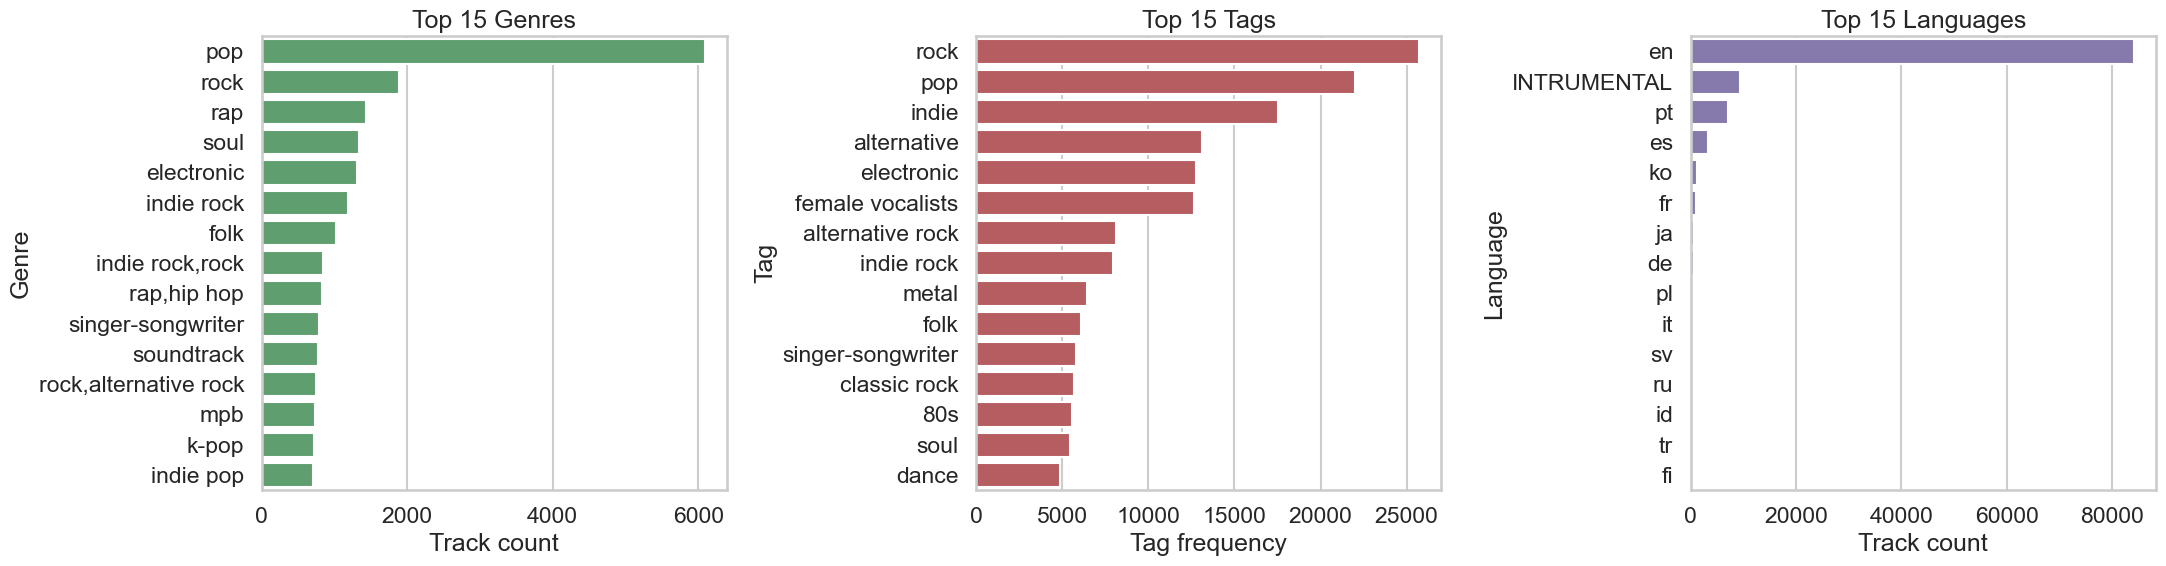

,metric,value
0,unique_genres,23520
1,unique_tags,19507
2,unique_languages,46


,top_genres,genre_count
0,pop,6092
1,rock,1887
2,rap,1431
3,soul,1337
4,electronic,1305
5,indie rock,1182
6,folk,1017
7,"indie rock,rock",840
8,"rap,hip hop",834
9,singer-songwriter,794


,top_tags,tag_count
0,rock,25733
1,pop,22016
2,indie,17539
3,alternative,13114
4,electronic,12773
5,female vocalists,12639
6,alternative rock,8103
7,indie rock,7944
8,metal,6459
9,folk,6106


,top_lang,lang_count
0,en,84103
1,INTRUMENTAL,9417
2,pt,7020
3,es,3225
4,ko,1145
5,fr,994
6,ja,615
7,de,577
8,pl,446
9,it,437


In [9]:
# 3.2 Genre / Tags / Language distribution

genre_counts = id_genres['genres'].fillna('unknown').astype(str).str.strip().replace('', 'unknown').value_counts()
lang_counts = id_lang['lang'].fillna('unknown').astype(str).str.strip().replace('', 'unknown').value_counts()

# tags are multi-label, split by comma
raw_tags = id_tags['tags'].fillna('').astype(str)
tag_series = raw_tags.str.split(',').explode().astype(str).str.strip().str.lower()
tag_series = tag_series[tag_series.ne('')]
tag_counts = tag_series.value_counts()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(x=genre_counts.head(15).values, y=genre_counts.head(15).index, ax=axes[0], color='#55A868')
axes[0].set_title('Top 15 Genres')
axes[0].set_xlabel('Track count')
axes[0].set_ylabel('Genre')

sns.barplot(x=tag_counts.head(15).values, y=tag_counts.head(15).index, ax=axes[1], color='#C44E52')
axes[1].set_title('Top 15 Tags')
axes[1].set_xlabel('Tag frequency')
axes[1].set_ylabel('Tag')

sns.barplot(x=lang_counts.head(15).values, y=lang_counts.head(15).index, ax=axes[2], color='#8172B3')
axes[2].set_title('Top 15 Languages')
axes[2].set_xlabel('Track count')
axes[2].set_ylabel('Language')

plt.tight_layout()
plt.show()

metadata_summary = pd.DataFrame([
    {'metric': 'unique_genres', 'value': int(genre_counts.shape[0])},
    {'metric': 'unique_tags', 'value': int(tag_counts.shape[0])},
    {'metric': 'unique_languages', 'value': int(lang_counts.shape[0])},
])

display(metadata_summary)

display(pd.DataFrame({
    'top_genres': genre_counts.head(10).index,
    'genre_count': genre_counts.head(10).values
}))
display(pd.DataFrame({
    'top_tags': tag_counts.head(10).index,
    'tag_count': tag_counts.head(10).values
}))
display(pd.DataFrame({
    'top_lang': lang_counts.head(10).index,
    'lang_count': lang_counts.head(10).values
}))

### Analysis Placeholder: Genre / Tag / Language Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## 4. User-Level EDA

This section summarizes user-side behavior:
- how many users are observed,
- how interactions are distributed across users,
- how concentrated heavy-user behavior is.

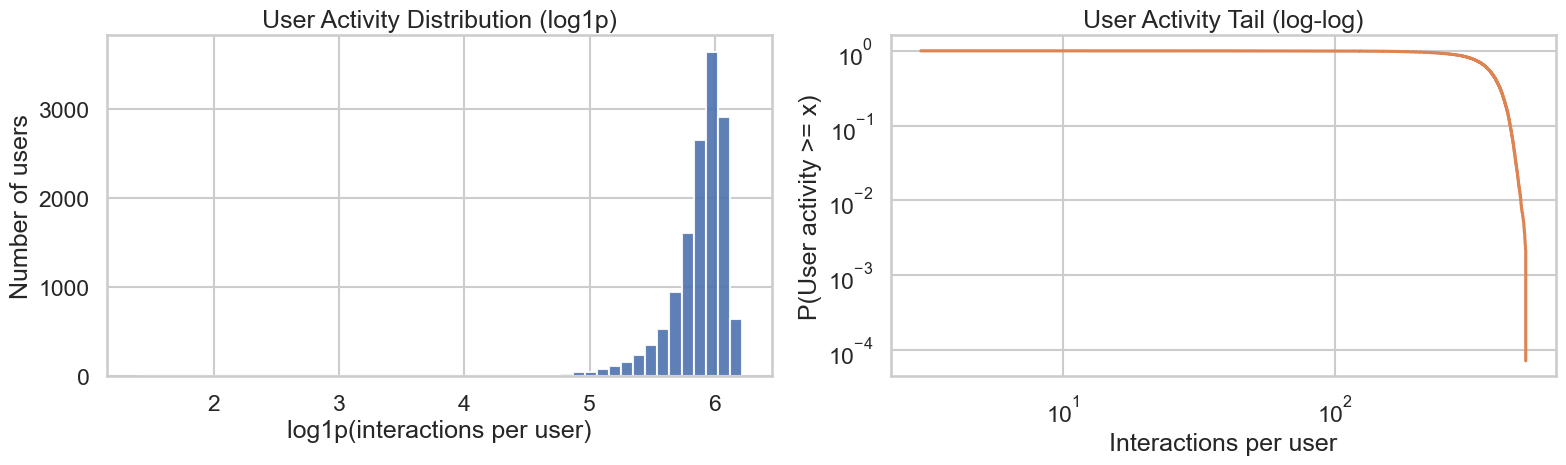

,metric,value
0,unique_users,14127
1,median_interactions_per_user,375
2,p90_interactions_per_user,438
3,p99_interactions_per_user,479
4,min_interactions_per_user,3
5,max_interactions_per_user,500


,interactions
user,
user_N9OKtRH0,500
user_JuUy0Pi6,500
user_Q8VSlThn,500
user_NAE2bHHI,500
user_Vrd41io2,500
user_nl3wcrsx,500
user_WOhttzwI,500
user_LFIMFlQR,500
user_F4xk4WW8,500


In [10]:
# 4.1 User listening-count distribution
user_counts = lh.groupby('user').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(np.log1p(user_counts.values), bins=50, color='#4C72B0', alpha=0.9)
axes[0].set_title('User Activity Distribution (log1p)')
axes[0].set_xlabel('log1p(interactions per user)')
axes[0].set_ylabel('Number of users')

# CCDF-like curve to show heavy tail
sorted_counts = np.sort(user_counts.values)[::-1]
ccdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
axes[1].plot(sorted_counts, ccdf, color='#DD8452')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Activity Tail (log-log)')
axes[1].set_xlabel('Interactions per user')
axes[1].set_ylabel('P(User activity >= x)')

plt.tight_layout()
plt.show()

user_summary = pd.DataFrame([
    {'metric': 'unique_users', 'value': int(user_counts.shape[0])},
    {'metric': 'median_interactions_per_user', 'value': int(user_counts.median())},
    {'metric': 'p90_interactions_per_user', 'value': int(user_counts.quantile(0.9))},
    {'metric': 'p99_interactions_per_user', 'value': int(user_counts.quantile(0.99))},
    {'metric': 'min_interactions_per_user', 'value': int(user_counts.min())},
    {'metric': 'max_interactions_per_user', 'value': int(user_counts.max())}
])

display(user_summary)
display(user_counts.head(15).rename('interactions').to_frame())


### Analysis Placeholder: User Listening-Count Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## 5. User + Song Interaction EDA

This section combines user and song behavior to inspect interaction dynamics:
- temporal interaction patterns,
- profile differences between heavy and light listener groups,
- interaction-derived signals useful for recommendation and generation evaluation.

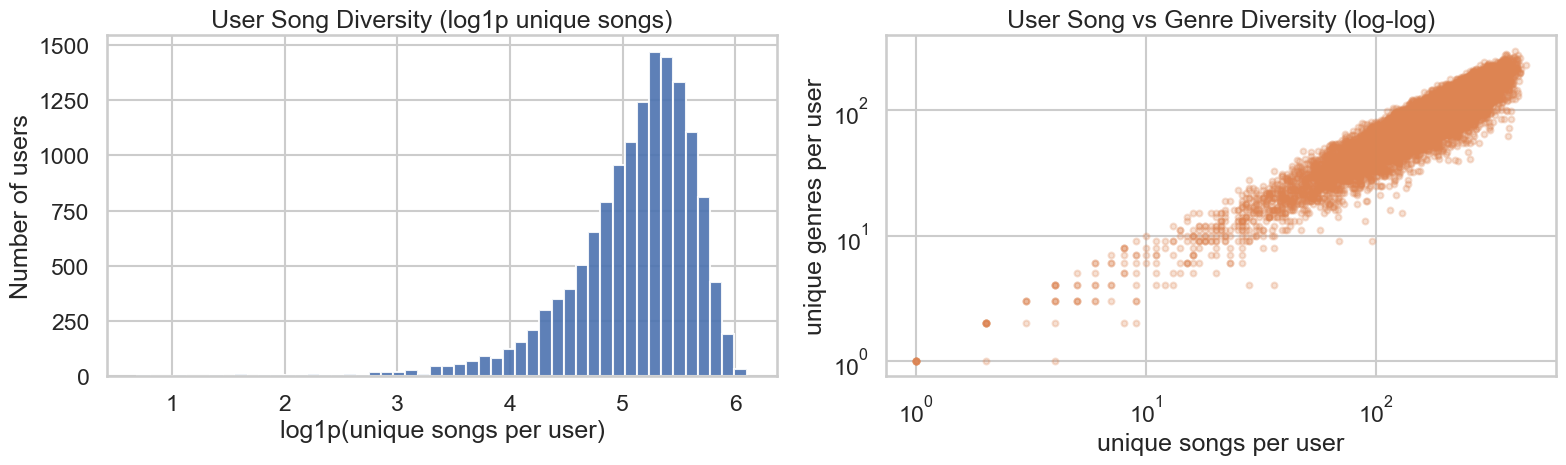

,metric,value
0,users_in_merged_profile,14127
1,median_unique_songs_per_user,182
2,median_unique_genres_per_user,93
3,median_unique_langs_per_user,4


,user,n_interactions,n_unique_songs,n_unique_genres,n_unique_langs
0,user_007XIjOr,440,160,97,3
1,user_00Y0Uqn9,399,149,83,4
2,user_00c8xHqc,391,150,86,3
3,user_00qujrxB,403,289,181,4
4,user_00s56GJz,386,204,132,4
5,user_019SS48x,423,148,91,2
6,user_01TB3qzT,386,218,121,4
7,user_01iQLLO6,481,277,147,3
8,user_01kaIjH9,382,249,84,9
9,user_01vPMYvi,432,54,26,3


In [11]:
# 5.0 User + Song merged profile (interaction-enriched view)

lh_merge = lh.rename(columns={'song': 'song_id'}).copy()

genre_map = id_genres.rename(columns={'id': 'song_id'}).copy()
lang_map = id_lang.rename(columns={'id': 'song_id'}).copy()

merged = lh_merge.merge(genre_map[['song_id', 'genres']], on='song_id', how='left')
merged = merged.merge(lang_map[['song_id', 'lang']], on='song_id', how='left')

merged['genres'] = merged['genres'].fillna('unknown').astype(str).str.strip().replace('', 'unknown')
merged['lang'] = merged['lang'].fillna('unknown').astype(str).str.strip().replace('', 'unknown')

user_song_profile = merged.groupby('user').agg(
    n_interactions=('song_id', 'size'),
    n_unique_songs=('song_id', 'nunique'),
    n_unique_genres=('genres', 'nunique'),
    n_unique_langs=('lang', 'nunique'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(np.log1p(user_song_profile['n_unique_songs']), bins=50, color='#4C72B0', alpha=0.9)
axes[0].set_title('User Song Diversity (log1p unique songs)')
axes[0].set_xlabel('log1p(unique songs per user)')
axes[0].set_ylabel('Number of users')

sample_profile = user_song_profile.sample(min(len(user_song_profile), 20000), random_state=42)
axes[1].scatter(
    sample_profile['n_unique_songs'],
    sample_profile['n_unique_genres'],
    alpha=0.25,
    s=18,
    color='#DD8452'
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Song vs Genre Diversity (log-log)')
axes[1].set_xlabel('unique songs per user')
axes[1].set_ylabel('unique genres per user')

plt.tight_layout()
plt.show()

user_song_summary = pd.DataFrame([
    {'metric': 'users_in_merged_profile', 'value': int(user_song_profile.shape[0])},
    {'metric': 'median_unique_songs_per_user', 'value': int(user_song_profile['n_unique_songs'].median())},
    {'metric': 'median_unique_genres_per_user', 'value': int(user_song_profile['n_unique_genres'].median())},
    {'metric': 'median_unique_langs_per_user', 'value': int(user_song_profile['n_unique_langs'].median())},
])

display(user_song_summary)
display(user_song_profile.head(15))

### Analysis Placeholder: User + Song Merged Profile

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

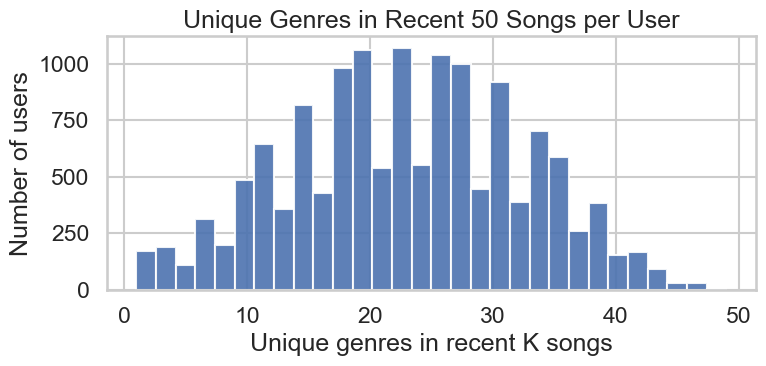

,metric,value
0,K,50.00
1,users_with_recent_k_profile,14127.00
2,median_unique_genres_recent_k,23.00
3,p90_unique_genres_recent_k,35.00
4,median_genre_diversity_ratio,0.46


,user,recent_k_songs,unique_genres_recent_k,genre_diversity_ratio
8282,user_aCj3MhMR,50,49,0.98
12997,user_upMNUYxi,50,49,0.98
1509,user_6QaILuXe,50,48,0.96
12293,user_rnO27prh,50,48,0.96
1716,user_7MaE84rJ,50,47,0.94
6659,user_T6NT38II,50,47,0.94
574,user_2N9sqH1V,50,47,0.94
1363,user_5idfch1m,50,47,0.94
11031,user_mA9BdGVk,50,47,0.94
4401,user_Ivbqrld0,50,47,0.94


In [17]:
# 5.0b Unique Genres in Recent K Songs per User
K = 50

lh_recent = lh.sort_values(['user', 'timestamp']).copy()
recent_k = lh_recent.groupby('user', group_keys=False).tail(K)

genre_map_recent = id_genres.rename(columns={'id': 'song'}).copy()
recent_k = recent_k.merge(genre_map_recent[['song', 'genres']], on='song', how='left')
recent_k['genres'] = recent_k['genres'].fillna('unknown').astype(str).str.strip().replace('', 'unknown')

recent_genre_div = (
    recent_k.groupby('user')
    .agg(
        recent_k_songs=('song', 'size'),
        unique_genres_recent_k=('genres', 'nunique')
    )
    .reset_index()
)

recent_genre_div['genre_diversity_ratio'] = (
    recent_genre_div['unique_genres_recent_k'] / recent_genre_div['recent_k_songs']
).round(4)

summary_recent_k = pd.DataFrame([
    {'metric': 'K', 'value': int(K)},
    {'metric': 'users_with_recent_k_profile', 'value': int(recent_genre_div.shape[0])},
    {'metric': 'median_unique_genres_recent_k', 'value': float(recent_genre_div['unique_genres_recent_k'].median())},
    {'metric': 'p90_unique_genres_recent_k', 'value': float(recent_genre_div['unique_genres_recent_k'].quantile(0.9))},
    {'metric': 'median_genre_diversity_ratio', 'value': float(recent_genre_div['genre_diversity_ratio'].median())},
])

plt.figure(figsize=(8, 4))
plt.hist(recent_genre_div['unique_genres_recent_k'], bins=30, color='#4C72B0', alpha=0.9)
plt.title(f'Unique Genres in Recent {K} Songs per User')
plt.xlabel('Unique genres in recent K songs')
plt.ylabel('Number of users')
plt.tight_layout()
plt.show()

display(summary_recent_k)
display(recent_genre_div.sort_values('unique_genres_recent_k', ascending=False).head(15))

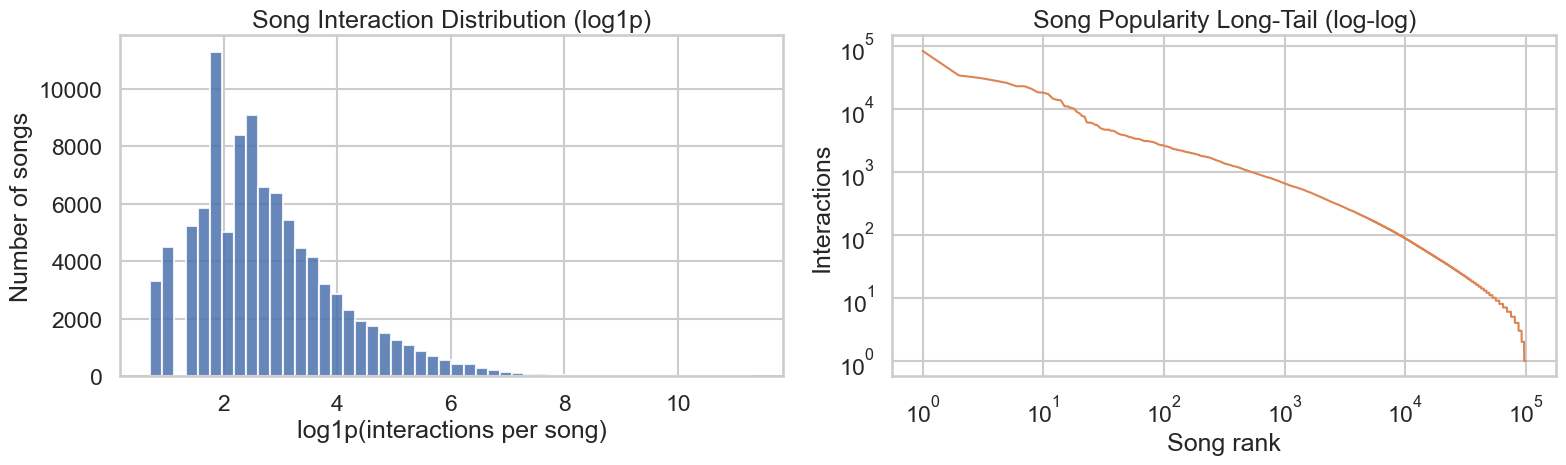

,metric,value
0,unique_songs_in_logs,99596
1,median_interactions_per_song,11
2,p90_interactions_per_song,88


,interactions
song,
32m5suoC94ytD8Ed,82871
YwURIu6eZDCJyuEf,33737
vkOg9ZAiUgUT87k6,30719
7Gsb7yKtAJNCvWez,27880
KKmk2QJLVj2Aqsjg,25640
Pf7CTDMAqnLhbcY2,22725
8LgQbYbM6Vz2my0y,22703
3shrACNQQ5eeQEAO,20643
xMkeAOwn6AzEeYGh,18239


In [12]:
# 3.1 Song distribution: popularity + long-tail
song_counts = lh.groupby('song').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of interactions per song (log scale on x)
axes[0].hist(np.log1p(song_counts.values), bins=50, color='#4C72B0', alpha=0.85)
axes[0].set_title('Song Interaction Distribution (log1p)')
axes[0].set_xlabel('log1p(interactions per song)')
axes[0].set_ylabel('Number of songs')

# Right: rank-frequency (long tail)
ranks = np.arange(1, len(song_counts) + 1)
axes[1].plot(ranks, song_counts.values, color='#DD8452', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Song Popularity Long-Tail (log-log)')
axes[1].set_xlabel('Song rank')
axes[1].set_ylabel('Interactions')

plt.tight_layout()
plt.show()

song_summary = pd.DataFrame([
    {'metric': 'unique_songs_in_logs', 'value': int(song_counts.shape[0])},
    {'metric': 'median_interactions_per_song', 'value': int(song_counts.median())},
    {'metric': 'p90_interactions_per_song', 'value': int(song_counts.quantile(0.9))},
])

display(song_summary)
display(song_counts.head(15).rename('interactions').to_frame())

### Analysis Placeholder: Song Popularity and Long-Tail

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

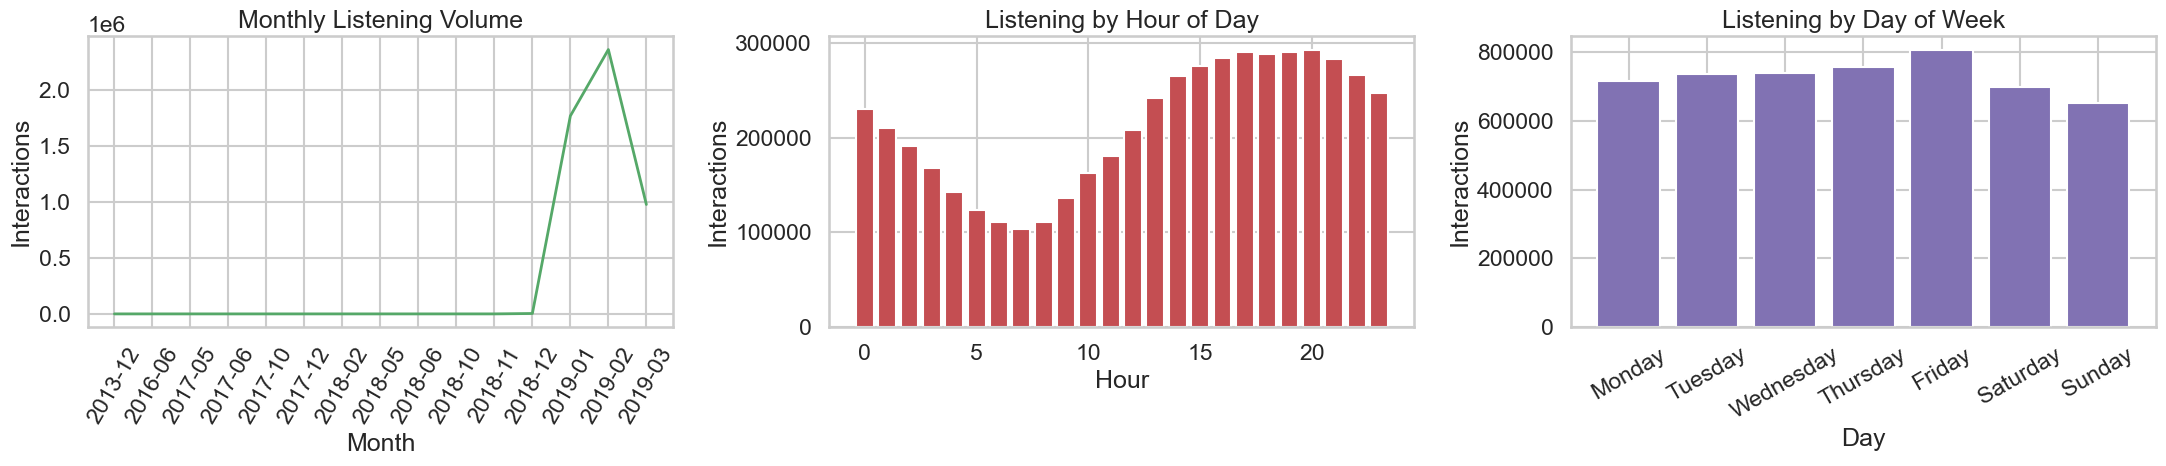

,metric,value
0,observed_date_span,2013-12-30 22:42:00 -> 2019-03-26 11:57:00
1,number_of_distinct_dates,133


In [13]:
# 5.1 User + Song interaction time distribution
lh_time = lh.copy()
lh_time['date'] = lh_time['timestamp'].dt.date
lh_time['month'] = lh_time['timestamp'].dt.to_period('M').astype(str)
lh_time['hour'] = lh_time['timestamp'].dt.hour
lh_time['dow'] = lh_time['timestamp'].dt.day_name()

monthly = lh_time.groupby('month').size()
hourly = lh_time.groupby('hour').size().reindex(range(24), fill_value=0)
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = lh_time['dow'].value_counts().reindex(dow_order).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

axes[0].plot(monthly.index, monthly.values, color='#55A868', linewidth=2)
axes[0].set_title('Monthly Listening Volume')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Interactions')
axes[0].tick_params(axis='x', rotation=60)

axes[1].bar(hourly.index, hourly.values, color='#C44E52')
axes[1].set_title('Listening by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Interactions')

axes[2].bar(dow_counts.index, dow_counts.values, color='#8172B3')
axes[2].set_title('Listening by Day of Week')
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Interactions')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

time_summary = pd.DataFrame([
    {'metric': 'observed_date_span', 'value': f"{lh_time['timestamp'].min()} -> {lh_time['timestamp'].max()}"},
    {'metric': 'number_of_distinct_dates', 'value': int(lh_time['date'].nunique())},
])

display(time_summary)

### Analysis Placeholder: User + Song Interaction Time Distribution

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

/var/folders/28/1r050w4j7j5c4jn87rdsh2hw0000gn/T/ipykernel_65785/138446831.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare, x='group', y='span_days', ax=axes[0], palette={'light':'#64B5CD', 'heavy':'#E17C73'})


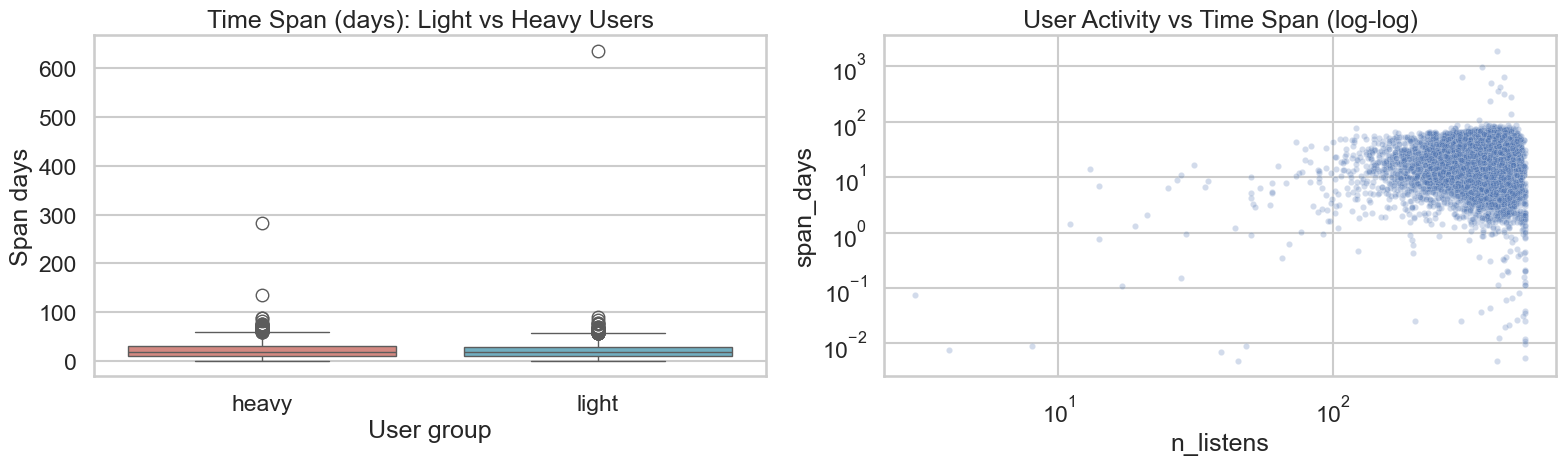

,metric,value
0,light_threshold_q20,312.0
1,heavy_threshold_q80,420.0


,users,median_listens,median_span_days,p90_span_days,median_unique_songs
group,,,,,
heavy,2831,438.0,17.7,42.32,206.0
light,2845,266.0,17.4,43.00,116.0


,metric,value
0,light_users_span_ge_30_days,647 / 2845
1,light_users_span_ge_90_days,1 / 2845


In [14]:
# 5.2 User + Song profile (heavy vs light listeners + temporal span)
user_profile = lh.groupby('user').agg(
    n_listens=('song', 'size'),
    first_ts=('timestamp', 'min'),
    last_ts=('timestamp', 'max'),
    n_unique_songs=('song', 'nunique')
).reset_index()

user_profile['span_days'] = (user_profile['last_ts'] - user_profile['first_ts']).dt.total_seconds() / 86400.0

q20 = user_profile['n_listens'].quantile(0.2)
q80 = user_profile['n_listens'].quantile(0.8)

user_profile['group'] = 'mid'
user_profile.loc[user_profile['n_listens'] <= q20, 'group'] = 'light'
user_profile.loc[user_profile['n_listens'] >= q80, 'group'] = 'heavy'

compare = user_profile[user_profile['group'].isin(['light', 'heavy'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=compare, x='group', y='span_days', ax=axes[0], palette={'light':'#64B5CD', 'heavy':'#E17C73'})
axes[0].set_title('Time Span (days): Light vs Heavy Users')
axes[0].set_xlabel('User group')
axes[0].set_ylabel('Span days')

sns.scatterplot(
    data=user_profile.sample(min(len(user_profile), 20000), random_state=42),
    x='n_listens', y='span_days', alpha=0.25, s=20, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('User Activity vs Time Span (log-log)')
axes[1].set_xlabel('n_listens')
axes[1].set_ylabel('span_days')

plt.tight_layout()
plt.show()

summary = compare.groupby('group').agg(
    users=('user', 'count'),
    median_listens=('n_listens', 'median'),
    median_span_days=('span_days', 'median'),
    p90_span_days=('span_days', lambda x: x.quantile(0.9)),
    median_unique_songs=('n_unique_songs', 'median')
).round(2)

threshold_summary = pd.DataFrame([
    {'metric': 'light_threshold_q20', 'value': round(float(q20), 2)},
    {'metric': 'heavy_threshold_q80', 'value': round(float(q80), 2)},
])

display(threshold_summary)
display(summary)

light_users = user_profile[user_profile['group'] == 'light']
light_span_summary = pd.DataFrame([
    {
        'metric': 'light_users_span_ge_30_days',
        'value': f"{int((light_users['span_days'] >= 30).sum())} / {len(light_users)}"
    },
    {
        'metric': 'light_users_span_ge_90_days',
        'value': f"{int((light_users['span_days'] >= 90).sum())} / {len(light_users)}"
    },
])

display(light_span_summary)

### Analysis Placeholder: User + Song Profile (Heavy vs Light)

- **What this figure/table suggests:**
- 

- **Potential explanation:**
- 

- **Implication for recommendation / generation pipeline:**
- 

- **Decision or follow-up check:**
- 

## User Generation Space Experiment

This section visualizes one user's recent listening history and generated candidate tracks in a comparable CLAP embedding space.

Encoder policy:
- prefer the fine-tuned CLAP checkpoint with attention pooling
- fall back to zero-shot CLAP if the fine-tuned checkpoint cannot be loaded

Color plan:
- blue: recent listened songs
- orange: generated candidates
- red: final rerank selections
- black star: centroid of the user's recent listening songs

In [8]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchaudio
from sklearn.decomposition import PCA

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.embed.embed_music4all import Config as FinetunedConfig
from src.embed.embed_music4all import load_finetuned_model_and_attention
from src.embed.embed_music4all_zeroshot import Config as ZeroShotConfig
from src.embed.embed_music4all_zeroshot import load_zeroshot_clap

RUN_DIR = REPO_ROOT / "outputs" / "recSongs" / "user_007XIjOr" / "20260330T234501Z-user_007XIjOr-suno"
MANIFEST_PATH = RUN_DIR / "run_manifest.json"
RERANK_PATH = RUN_DIR / "rerank_results.json"
LISTENING_HISTORY_PATH = REPO_ROOT / "music4all" / "listening_history.csv"
ID_INFO_PATH = REPO_ROOT / "music4all" / "id_information.csv"
AUDIO_DIR = REPO_ROOT / "music4all" / "audios"

TOP_RECENT = 20
SEED = 42

In [9]:
def load_listening_history(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    if len(df.columns) == 1 and "\t" in df.columns[0]:
        fixed = pd.read_csv(path, sep="\t", header=None)
        fixed.columns = ["user", "song", "timestamp"][: fixed.shape[1]]
        df = fixed
    lower_map = {c.lower(): c for c in df.columns}
    user_col = lower_map.get("user") or lower_map.get("user_id")
    song_col = lower_map.get("song") or lower_map.get("song_id")
    ts_col = lower_map.get("timestamp")
    if user_col is None or song_col is None:
        raise ValueError("Could not find user/song columns in listening_history.csv")
    out = df.rename(columns={user_col: "user_id", song_col: "song_id"}).copy()
    out["user_id"] = out["user_id"].astype(str)
    out["song_id"] = out["song_id"].astype(str)
    if ts_col is not None:
        out["timestamp"] = pd.to_datetime(out[ts_col], errors="coerce")
    else:
        out["timestamp"] = pd.NaT
    return out[["user_id", "song_id", "timestamp"]]


def load_id_information(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    if "id" not in df.columns:
        df = pd.read_csv(path, sep="\t", header=None, names=["id", "artist", "song", "album_name"])
    df["id"] = df["id"].astype(str)
    return df


def get_recent_unique_song_ids(history_df: pd.DataFrame, user_id: str, top_recent: int) -> list[str]:
    user_df = history_df.loc[history_df["user_id"] == user_id].copy()
    user_df = user_df.sort_values("timestamp", ascending=False, na_position="last")
    seen = set()
    recent_ids = []
    for song_id in user_df["song_id"].tolist():
        if song_id not in seen:
            recent_ids.append(song_id)
            seen.add(song_id)
        if len(recent_ids) >= top_recent:
            break
    return recent_ids


def prepare_audio_chunks(path: Path, sample_rate: int, num_chunks: int, chunk_samples: int) -> torch.Tensor:
    waveform, sr = torchaudio.load(str(path))
    if sr != sample_rate:
        resampler = torchaudio.transforms.Resample(sr, sample_rate)
        waveform = resampler(waveform)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    waveform = waveform.squeeze(0)
    total_len = waveform.shape[0]
    chunks = []
    if total_len <= chunk_samples:
        padded = F.pad(waveform, (0, chunk_samples - total_len))
        for _ in range(num_chunks):
            chunks.append(padded)
    else:
        max_start = total_len - chunk_samples
        start_points = np.linspace(0, max_start, num_chunks).astype(int)
        for start in start_points:
            chunks.append(waveform[start : start + chunk_samples])
    return torch.stack(chunks)


def embed_audio_file(
    path: Path,
    *,
    model: torch.nn.Module,
    attention_pool: torch.nn.Module | None,
    embedding_dim: int,
    device: str,
    sample_rate: int,
    num_chunks: int,
    chunk_samples: int,
) -> np.ndarray:
    chunks = prepare_audio_chunks(
        path,
        sample_rate=sample_rate,
        num_chunks=num_chunks,
        chunk_samples=chunk_samples,
    ).unsqueeze(0)
    _, observed_num_chunks, samples = chunks.shape
    with torch.no_grad():
        flat_audio = chunks.view(observed_num_chunks, samples).to(device)
        output_dict = model.audio_branch({"waveform": flat_audio})
        if isinstance(output_dict, dict):
            flat_audio_features = output_dict.get("embedding", list(output_dict.values())[0])
        else:
            flat_audio_features = output_dict
        if hasattr(model, "audio_projection"):
            flat_audio_features = model.audio_projection(flat_audio_features)
        unflattened = flat_audio_features.view(1, observed_num_chunks, embedding_dim)
        if attention_pool is None:
            pooled = unflattened.mean(dim=1)
        else:
            pooled = attention_pool(unflattened)
        pooled = F.normalize(pooled, dim=-1)
        return pooled.squeeze(0).cpu().numpy().astype(np.float32)


def load_preferred_audio_encoder() -> tuple[torch.nn.Module, torch.nn.Module | None, int, dict]:
    try:
        model, attention_pool, embedding_dim = load_finetuned_model_and_attention(FinetunedConfig.DEVICE)
        return model, attention_pool, int(embedding_dim), {
            "encoder_name": "finetuned",
            "device": FinetunedConfig.DEVICE,
            "sample_rate": FinetunedConfig.SAMPLE_RATE,
            "num_chunks": FinetunedConfig.NUM_CHUNKS,
            "chunk_samples": FinetunedConfig.CHUNK_SAMPLES,
        }
    except Exception as exc:
        print(f"Falling back to zero-shot CLAP: {exc}")
        model = load_zeroshot_clap(ZeroShotConfig.DEVICE)
        with torch.no_grad():
            dummy_wave = torch.zeros(1, ZeroShotConfig.CHUNK_SAMPLES).to(ZeroShotConfig.DEVICE)
            dummy_out = model.audio_branch({"waveform": dummy_wave})
            if isinstance(dummy_out, dict):
                dummy_emb = dummy_out.get("embedding", list(dummy_out.values())[0])
            else:
                dummy_emb = dummy_out
            if hasattr(model, "audio_projection"):
                dummy_emb = model.audio_projection(dummy_emb)
            embedding_dim = int(dummy_emb.shape[-1])
        return model, None, embedding_dim, {
            "encoder_name": "zeroshot",
            "device": ZeroShotConfig.DEVICE,
            "sample_rate": ZeroShotConfig.SAMPLE_RATE,
            "num_chunks": ZeroShotConfig.NUM_CHUNKS,
            "chunk_samples": ZeroShotConfig.CHUNK_SAMPLES,
        }


def project_to_2d(matrix: np.ndarray) -> np.ndarray:
    if HAS_UMAP and matrix.shape[0] >= 5:
        reducer = umap.UMAP(n_components=2, random_state=SEED)
        return reducer.fit_transform(matrix)
    reducer = PCA(n_components=2, random_state=SEED)
    return reducer.fit_transform(matrix)

In [10]:
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
rerank = json.loads(RERANK_PATH.read_text(encoding="utf-8"))
user_id = manifest["user_id"]

history_df = load_listening_history(LISTENING_HISTORY_PATH)
id_info_df = load_id_information(ID_INFO_PATH)
id_to_label = {
    row["id"]: f"{row.get('artist', 'Unknown')} - {row.get('song', row['id'])}"
    for _, row in id_info_df.iterrows()
}

recent_song_ids = get_recent_unique_song_ids(history_df, user_id=user_id, top_recent=TOP_RECENT)
recent_audio_paths = []
for song_id in recent_song_ids:
    audio_path = AUDIO_DIR / f"{song_id}.mp3"
    if audio_path.exists():
        recent_audio_paths.append((song_id, audio_path))

candidate_rows = rerank["candidates"]
selected_paths = {item["path"] for item in rerank["final_selected_tracks"]}

model, attention_pool, embedding_dim, encoder_cfg = load_preferred_audio_encoder()
print(f"Using encoder: {encoder_cfg['encoder_name']}")

device = encoder_cfg["device"]
sample_rate = encoder_cfg["sample_rate"]
num_chunks = encoder_cfg["num_chunks"]
chunk_samples = encoder_cfg["chunk_samples"]

records = []
recent_embeddings = []
for song_id, audio_path in recent_audio_paths:
    emb = embed_audio_file(
        audio_path,
        model=model,
        attention_pool=attention_pool,
        embedding_dim=embedding_dim,
        device=device,
        sample_rate=sample_rate,
        num_chunks=num_chunks,
        chunk_samples=chunk_samples,
    )
    recent_embeddings.append(emb)
    records.append({
        "label": id_to_label.get(song_id, song_id),
        "group": "recent_listens",
        "path": str(audio_path),
        "score": np.nan,
        "embedding": emb,
    })

for item in candidate_rows:
    audio_path = Path(item["path"])
    emb = embed_audio_file(
        audio_path,
        model=model,
        attention_pool=attention_pool,
        embedding_dim=embedding_dim,
        device=device,
        sample_rate=sample_rate,
        num_chunks=num_chunks,
        chunk_samples=chunk_samples,
    )
    records.append({
        "label": item.get("title") or audio_path.stem,
        "group": "selected_generated" if str(audio_path) in selected_paths else "generated_candidates",
        "path": str(audio_path),
        "score": item.get("clap_cosine_score"),
        "embedding": emb,
    })

recent_centroid = np.mean(np.stack(recent_embeddings), axis=0)
records.append({
    "label": f"{user_id} recent centroid",
    "group": "recent_centroid",
    "path": "",
    "score": np.nan,
    "embedding": recent_centroid,
})

plot_df = pd.DataFrame(records)
plot_matrix = np.stack(plot_df["embedding"].to_list())
coords = project_to_2d(plot_matrix)
plot_df["x"] = coords[:, 0]
plot_df["y"] = coords[:, 1]
plot_df["encoder"] = encoder_cfg["encoder_name"]
plot_df = plot_df.drop(columns=["embedding"])

plot_df.head()

Loading CLAP base model from /Users/itsnotjerryh/Desktop/Github/Gen4Rec/weights/clap/music_audioset_epoch_15_esc_90.14.pt...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Load the specified checkpoint /Users/itsnotjerryh/Desktop/Github/Gen4Rec/weights/clap/music_audioset_epoch_15_esc_90.14.pt from users.
Load Checkpoint...
logit_scale_a 	 Loaded
logit_scale_t 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_real.weight 	 Loaded
audio_branch.spectrogram_extractor.stft.conv_imag.weight 	 Loaded
audio_branch.logmel_extractor.melW 	 Loaded
audio_branch.bn0.weight 	 Loaded
audio_branch.bn0.bias 	 Loaded
audio_branch.patch_embed.proj.weight 	 Loaded
audio_branch.patch_embed.proj.bias 	 Loaded
audio_branch.patch_embed.norm.weight 	 Loaded
audio_branch.patch_embed.norm.bias 	 Loaded
audio_branch.layers.0.blocks.0.norm1.weight 	 Loaded
audio_branch.layers.0.blocks.0.norm1.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.relative_position_bias_table 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn.qkv.bias 	 Loaded
audio_branch.layers.0.blocks.0.attn.proj.weight 	 Loaded
audio_branch.layers.0.blocks.0.attn

,label,group,path,score,x,y,encoder
0,Zee Avi - Rainbow Connection,recent_listens,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/mus...,NaN,-0.151964,0.386880,finetuned
1,Julia Holter - Maxim's II,recent_listens,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/mus...,NaN,-0.339661,-0.165158,finetuned
2,Regina Spektor - One More Time With Feeling,recent_listens,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/mus...,NaN,-0.201407,0.062172,finetuned
3,Julia Holter - Silhouette,recent_listens,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/mus...,NaN,-0.303162,-0.007186,finetuned
4,Regina Spektor - Oh Marcello,recent_listens,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/mus...,NaN,-0.000012,0.441908,finetuned


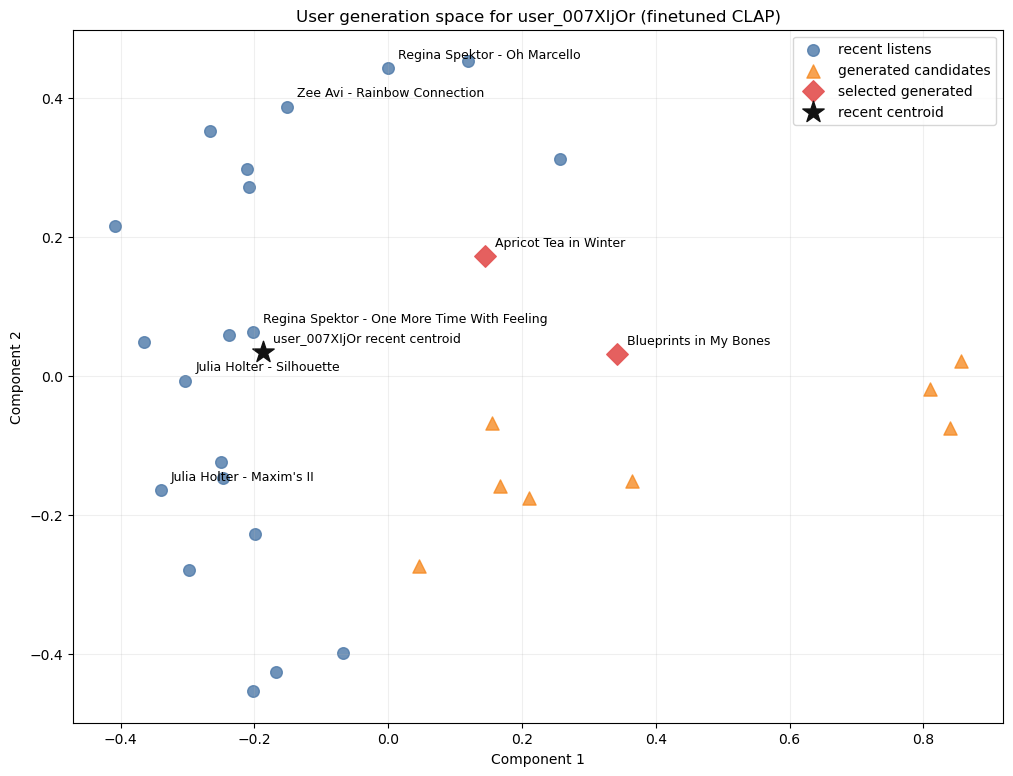

,encoder,group,label,score,path
22,finetuned,generated_candidates,Blueprints in My Bones,0.366808,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
23,finetuned,generated_candidates,Porch Light Letters,0.328984,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
24,finetuned,generated_candidates,Ceramic Mugs,0.322436,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
25,finetuned,generated_candidates,Ceramic Mugs,0.307728,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
26,finetuned,generated_candidates,All The Quiet Things,0.293303,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
27,finetuned,generated_candidates,Apricot Tea in Winter,0.196527,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
28,finetuned,generated_candidates,All The Quiet Things,0.185274,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
29,finetuned,generated_candidates,Porch Light Letters,0.183858,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...
30,finetuned,recent_centroid,user_007XIjOr recent centroid,NaN,
20,finetuned,selected_generated,Apricot Tea in Winter,0.458007,/Users/itsnotjerryh/Desktop/Github/Gen4Rec/out...


In [ ]:
plt.figure(figsize=(12, 9))
style_map = {
    "recent_listens": {"color": "#4C78A8", "marker": "o", "size": 70, "alpha": 0.8},
    "generated_candidates": {"color": "#F58518", "marker": "^", "size": 90, "alpha": 0.75},
    "selected_generated": {"color": "#E45756", "marker": "D", "size": 120, "alpha": 0.95},
    "recent_centroid": {"color": "#111111", "marker": "*", "size": 260, "alpha": 1.0},
}

for group, style in style_map.items():
    group_df = plot_df.loc[plot_df["group"] == group]
    if group_df.empty:
        continue
    plt.scatter(
        group_df["x"],
        group_df["y"],
        c=style["color"],
        marker=style["marker"],
        s=style["size"],
        alpha=style["alpha"],
        label=group.replace("_", " "),
    )

annotate_df = plot_df.loc[plot_df["group"].isin(["selected_generated", "recent_centroid"])].copy()
annotate_df = pd.concat([
    annotate_df,
    # Labels the recent listened songs
    plot_df.loc[plot_df["group"] == "recent_listens"].head(5),
], ignore_index=True).drop_duplicates(subset=["label", "group"])

for _, row in annotate_df.iterrows():
    plt.text(
        row["x"] + 0.015,
        row["y"] + 0.01,
        row["label"],
        fontsize=9,
        ha="left",
        va="bottom",
    )

encoder_name = plot_df["encoder"].iloc[0]
plt.title(f"User generation space for {user_id} ({encoder_name} CLAP)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

summary_cols = ["encoder", "group", "label", "score", "path"]
display(plot_df.loc[plot_df["group"] != "recent_listens", summary_cols].sort_values(["group", "score"], ascending=[True, False]))